In [2]:
import math
import random
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

In [3]:

class Value:
    def __init__(self, data, _children=(), _op=()):
        self.data = data
        self.grad = 0
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op

    def __repr__(self):
        return f"Value(data={self.data}, grad={self.grad})"

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')
        def _backward():
            self.grad  += 1.0 * out.grad
            other.grad += 1.0 * out.grad
        out._backward = _backward
        return out

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*')
        def _backward():
            self.grad  += other.data * out.grad
            other.grad += self.data  * out.grad
        out._backward = _backward
        return out

    def __pow__(self, exponent):
        assert isinstance(exponent, (int, float))
        out = Value(self.data ** exponent, (self,), f"**{exponent}")
        def _backward():
            self.grad += exponent * (self.data ** (exponent - 1)) * out.grad
        out._backward = _backward
        return out

    def tanh(self):
        x   = self.data
        t   = (math.exp(2*x) - 1) / (math.exp(2*x) + 1)
        out = Value(t, (self,), 'tanh')
        def _backward():
            self.grad += (1 - t**2) * out.grad
        out._backward = _backward
        return out

    def relu(self):
        out = Value(max(0, self.data), (self,), 'ReLU')
        def _backward():
            self.grad += (out.data > 0) * out.grad
        out._backward = _backward
        return out

    def sigmoid(self):
        s   = 1 / (1 + math.exp(-self.data))
        out = Value(s, (self,), 'sigmoid')
        def _backward():
            self.grad += s * (1 - s) * out.grad
        out._backward = _backward
        return out

    def leaky_relu(self, alpha=0.01):
        val = self.data if self.data > 0 else alpha * self.data
        out = Value(val, (self,), 'LeakyReLU')
        def _backward():
            self.grad += (1.0 if self.data > 0 else alpha) * out.grad
        out._backward = _backward
        return out

    def __neg__(self):         return self * -1
    def __sub__(self, other):  return self + (-other)
    def __truediv__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        return self * other**-1
    def __radd__(self, other): return self + other
    def __rmul__(self, other): return self * other
    def __rsub__(self, other): return Value(other) + (-self)

    def backward(self):
        topo, visited = [], set()
        def build(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build(child)
                topo.append(v)
        build(self)
        self.grad = 1.0
        for node in reversed(topo):
            node._backward()

In [4]:
class Neuron:
    ACTIVATIONS = {
        'tanh':       lambda v: v.tanh(),
        'relu':       lambda v: v.relu(),
        'sigmoid':    lambda v: v.sigmoid(),
        'leaky_relu': lambda v: v.leaky_relu(),
    }

    def __init__(self, nin, activation='tanh'):
        self.w = [Value(random.uniform(-1, 1)) for _ in range(nin)]
        self.b = Value(0.0)
        self.activation = activation

    def __call__(self, x):
        act = sum((wi * xi for wi, xi in zip(self.w, x)), self.b)
        fn  = self.ACTIVATIONS.get(self.activation)
        return fn(act) if fn else act

    def parameters(self):
        return self.w + [self.b]


class Layer:
    def __init__(self, nin, nout, activation='tanh', output=False):
        act = None if output else activation
        self.neurons = [Neuron(nin, activation=act) for _ in range(nout)]

    def __call__(self, x):
        return [n(x) for n in self.neurons]

    def parameters(self):
        return [p for n in self.neurons for p in n.parameters()]


class MLP:
    def __init__(self, nin, layer_sizes, activation='tanh'):
        sizes = [nin] + layer_sizes
        self.layers = [
            Layer(sizes[i], sizes[i+1],
                  activation=activation,
                  output=(i == len(layer_sizes) - 1))
            for i in range(len(layer_sizes))
        ]

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x[0] if len(x) == 1 else x

    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]

In [5]:
def train(activation, steps=400, lr=0.02, seed=42):
    random.seed(seed)

    X = [[4.0, 3.0], [-2.0, -1.0], [1.0, -1.5], [-2.0, -2.0],
         [-3.0, -5.0], [4.0, -1.0], [7.0, 9.0], [-1.0, 5.0]]
    y = [1.0, 1.0, -1.0, 1.0, 1.0, -1.0, 1.0, -1.0]

    model  = MLP(2, [4, 4, 1], activation=activation)
    losses = []

    for _ in range(steps):
        ypred = [model(x) for x in X]
        loss  = sum(((yp - Value(yt))**2 for yp, yt in zip(ypred, y)), Value(0.0))

        # backward pass
        for p in model.parameters():
            p.grad = 0
        loss.backward()

        # gradient descent update
        for p in model.parameters():
            p.data -= lr * p.grad

        losses.append(loss.data)

    return losses

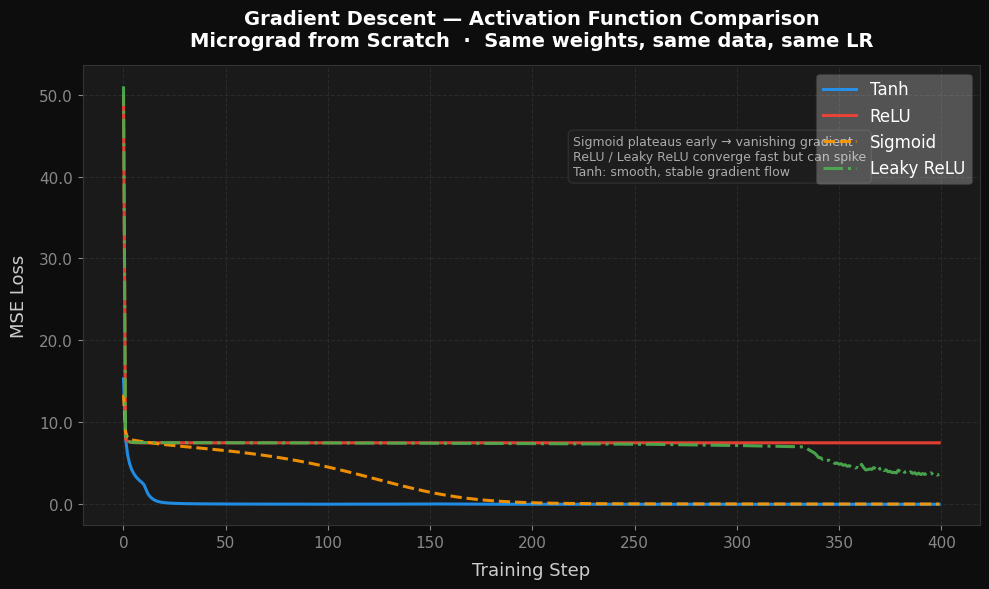

In [7]:
ACTIVATIONS = {
    'Tanh':       ('tanh',       '#2196F3', '-'),
    'ReLU':       ('relu',       '#F44336', '-'),
    'Sigmoid':    ('sigmoid',    '#FF9800', '--'),
    'Leaky ReLU': ('leaky_relu', '#4CAF50', '-.'),
}

STEPS = 400
LR    = 0.02

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('#0d0d0d')
ax.set_facecolor('#1a1a1a')

for label, (key, color, ls) in ACTIVATIONS.items():
    losses = train(key, steps=STEPS, lr=LR)
    ax.plot(losses, color=color, linestyle=ls, linewidth=2.2,
            label=label, alpha=0.92)

ax.set_xlabel('Training Step',  fontsize=13, color='#cccccc', labelpad=8)
ax.set_ylabel('MSE Loss',       fontsize=13, color='#cccccc', labelpad=8)
ax.set_title(
    'Gradient Descent — Activation Function Comparison\n'
    'Micrograd from Scratch  ·  Same weights, same data, same LR',
    fontsize=14, color='#ffffff', fontweight='bold', pad=14
)

ax.tick_params(colors='#888888', labelsize=11)
for spine in ax.spines.values():
    spine.set_edgecolor('#333333')

ax.grid(True, color='#2a2a2a', linewidth=0.8, linestyle='--')
ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))

legend = ax.legend(fontsize=12, framealpha=0.25, edgecolor='#444444',
                   labelcolor='white', loc='upper right')

ax.annotate(
    'Sigmoid plateaus early → vanishing gradient\n'
    'ReLU / Leaky ReLU converge fast but can spike\n'
    'Tanh: smooth, stable gradient flow',
    xy=(STEPS * 0.55, ax.get_ylim()[1] * 0.75 if ax.get_ylim()[1] > 1 else 1.2),
    fontsize=9, color='#aaaaaa',
    bbox=dict(boxstyle='round,pad=0.4', fc='#1e1e1e', ec='#333333', alpha=0.8)
)

plt.tight_layout()
plt.show()